In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving hosp.csv to hosp.csv
User uploaded file "hosp.csv" with length 4681925 bytes


After running the cell, a file selection dialog will appear. You can then navigate to your downloads folder and select your dataset file(s). Once uploaded, the files will be accessible in your Colab environment.

# Task
Perform a comprehensive data analysis on the "hosp.csv" dataset, which includes data loading, initial inspection, cleaning, preprocessing, exploratory data analysis (EDA), feature engineering, training and evaluating both machine learning and deep learning models, visualizing model results, and summarizing all insights.

## Load Dataset

### Subtask:
Load the hosp.csv file into a pandas DataFrame to begin the analysis.


**Reasoning**:
First, I'll import the pandas library to enable data manipulation, then load the 'hosp.csv' file into a DataFrame named `df` using a semicolon as the delimiter. Finally, I will display the first five rows and column data types to ensure the data is loaded correctly.



In [2]:
import pandas as pd

df = pd.read_csv('hosp.csv', delimiter=';')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nData types of each column:")
print(df.info())

First 5 rows of the DataFrame:
   year  facility_number     facility_name  begin_date    end_date  \
0  2009      106010735.0  ALAMEDA HOSPITAL  07/01/2008  06/30/2009   
1  2009      106010735.0  ALAMEDA HOSPITAL  07/01/2008  06/30/2009   
2  2009      106010735.0  ALAMEDA HOSPITAL  07/01/2008  06/30/2009   
3  2009      106010735.0  ALAMEDA HOSPITAL  07/01/2008  06/30/2009   
4  2009      106010735.0  ALAMEDA HOSPITAL  07/01/2008  06/30/2009   

  county_name type_of_control                 hours_type  productive_hours  \
0     Alameda        District   Management & Supervision             63558   
1     Alameda        District    Technician & Specialist            163706   
2     Alameda        District           Registered Nurse            180034   
3     Alameda        District  Licensed Vocational Nurse             22323   
4     Alameda        District          Aides & Orderlies             97205   

   productive_hours_per_adjusted_patient_day  
0                               

## Initial Data Inspection

### Subtask:
Inspect the dataset's basic structure, data types, and check for missing values and duplicates to understand its initial state.


**Reasoning**:
To thoroughly inspect the dataset as requested, I will generate a code block that prints the DataFrame's shape, calculates and displays missing values per column, counts duplicate rows, and provides descriptive statistics for both numerical and categorical columns. This will provide a comprehensive initial understanding of the data's structure and quality.



In [3]:
print("\nShape of the DataFrame (rows, columns):")
print(df.shape)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTotal number of duplicate rows:")
print(df.duplicated().sum())

print("\nDescriptive statistics for numerical columns:")
print(df.describe())

print("\nDescriptive statistics for categorical columns:")
print(df.describe(include='object'))


Shape of the DataFrame (rows, columns):
(37604, 10)

Missing values per column:
year                                           0
facility_number                               85
facility_name                                 85
begin_date                                    85
end_date                                      85
county_name                                    0
type_of_control                               85
hours_type                                     0
productive_hours                               0
productive_hours_per_adjusted_patient_day    187
dtype: int64

Total number of duplicate rows:
0

Descriptive statistics for numerical columns:
               year  facility_number  productive_hours  \
count  37604.000000     3.751900e+04      3.760400e+04   
mean    2010.987794     1.062795e+08      4.209184e+05   
std        1.412740     1.373940e+05      5.593442e+06   
min     2009.000000     1.060107e+08      0.000000e+00   
25%     2010.000000     1.061903e+08      7.

## Data Cleaning and Preprocessing

### Subtask:
Handle missing values, address any inconsistencies or errors in the data, and perform necessary data type conversions or basic feature engineering to prepare the data for analysis.


**Reasoning**:
To address missing values and data type inconsistencies, I will first convert the 'begin_date' and 'end_date' columns to datetime objects. Then, I will identify any remaining missing values, drop rows containing them, and finally, verify the DataFrame's shape and absence of missing values.



In [4]:
df['begin_date'] = pd.to_datetime(df['begin_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

print("\nMissing values per column after date conversion:")
print(df.isnull().sum())

print("\nShape of the DataFrame before dropping missing values:", df.shape)
df.dropna(inplace=True)
print("Shape of the DataFrame after dropping missing values:", df.shape)

print("\nMissing values per column after dropping rows:")
print(df.isnull().sum())


Missing values per column after date conversion:
year                                           0
facility_number                               85
facility_name                                 85
begin_date                                    85
end_date                                      85
county_name                                    0
type_of_control                               85
hours_type                                     0
productive_hours                               0
productive_hours_per_adjusted_patient_day    187
dtype: int64

Shape of the DataFrame before dropping missing values: (37604, 10)
Shape of the DataFrame after dropping missing values: (37332, 10)

Missing values per column after dropping rows:
year                                         0
facility_number                              0
facility_name                                0
begin_date                                   0
end_date                                     0
county_name                   

## Exploratory Data Analysis (EDA)

### Subtask:
Perform in-depth exploratory data analysis. This includes calculating descriptive statistics, analyzing distributions of key variables, and identifying potential outliers or anomalies. We will use various plots such as histograms, box plots, and count plots to visualize these aspects.


**Reasoning**:
To begin the exploratory data analysis, I will display the updated descriptive statistics for numerical columns. Then, I will generate histograms to visualize the distributions of 'productive_hours' and 'productive_hours_per_adjusted_patient_day', followed by box plots for these same variables to identify potential outliers. Finally, I will create count plots for 'county_name', 'type_of_control', and 'hours_type' to show the distribution of categorical variables, limiting 'county_name' to the top 10 for better readability.




Descriptive statistics for numerical columns after cleaning:
               year  facility_number                     begin_date  \
count  37332.000000     3.733200e+04                          37332   
mean    2010.987250     1.062804e+08  2010-10-02 21:34:25.573770752   
min     2009.000000     1.060107e+08            2008-01-01 00:00:00   
25%     2010.000000     1.061903e+08            2009-07-01 00:00:00   
50%     2011.000000     1.063011e+08            2010-10-01 00:00:00   
75%     2012.000000     1.063714e+08            2012-01-01 00:00:00   
max     2013.000000     1.065810e+08            2013-10-14 00:00:00   
std        1.412886     1.370779e+05                            NaN   

                            end_date  productive_hours  \
count                          37332      3.733200e+04   
mean   2011-09-29 19:56:43.278688512      2.119600e+05   
min              2009-01-15 00:00:00      0.000000e+00   
25%              2010-06-30 00:00:00      8.224500e+03   
50%     

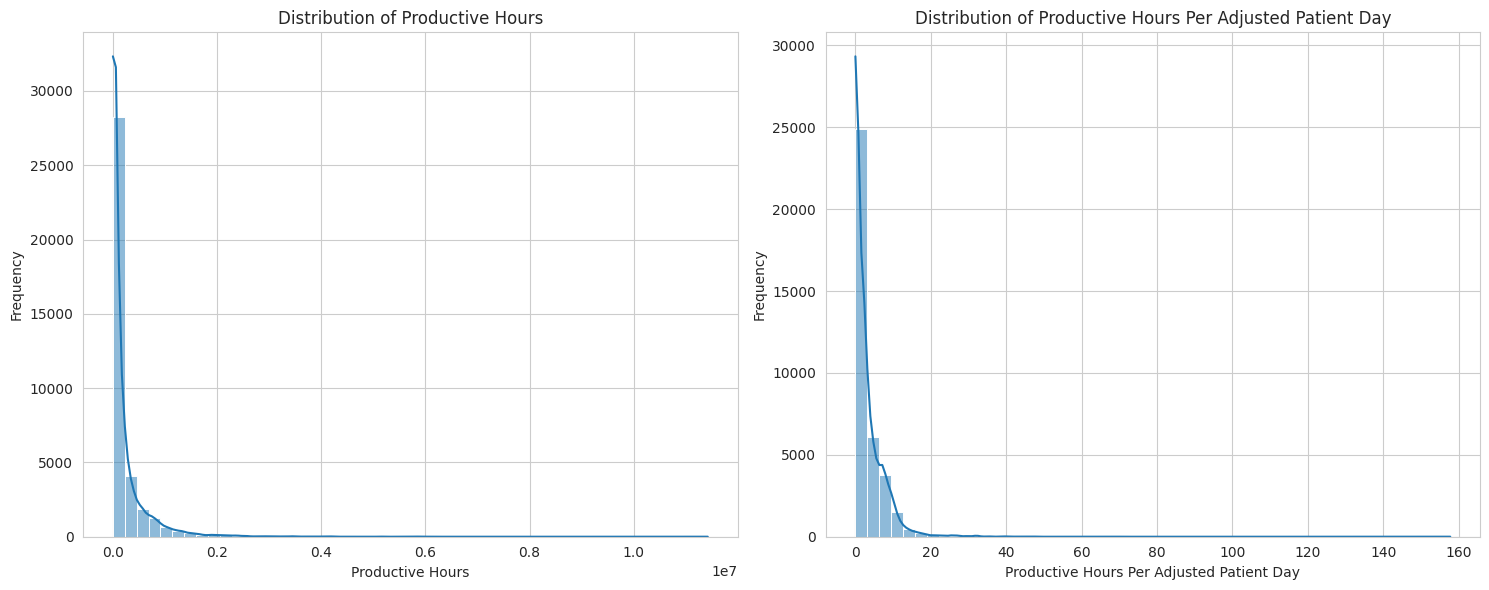

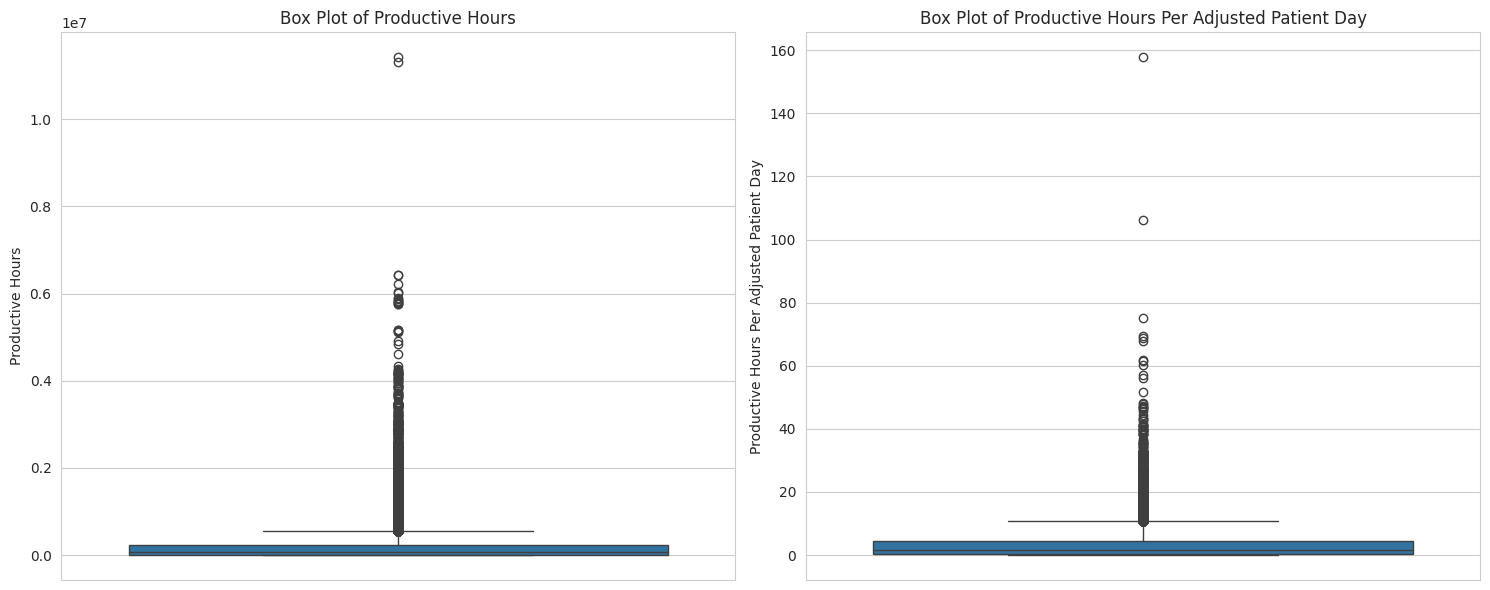

/tmp/ipykernel_516/122586043.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['county_name'], order=top_10_counties, palette='viridis')
/tmp/ipykernel_516/122586043.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['type_of_control'], palette='magma')
/tmp/ipykernel_516/122586043.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['hours_type'], palette='plasma')


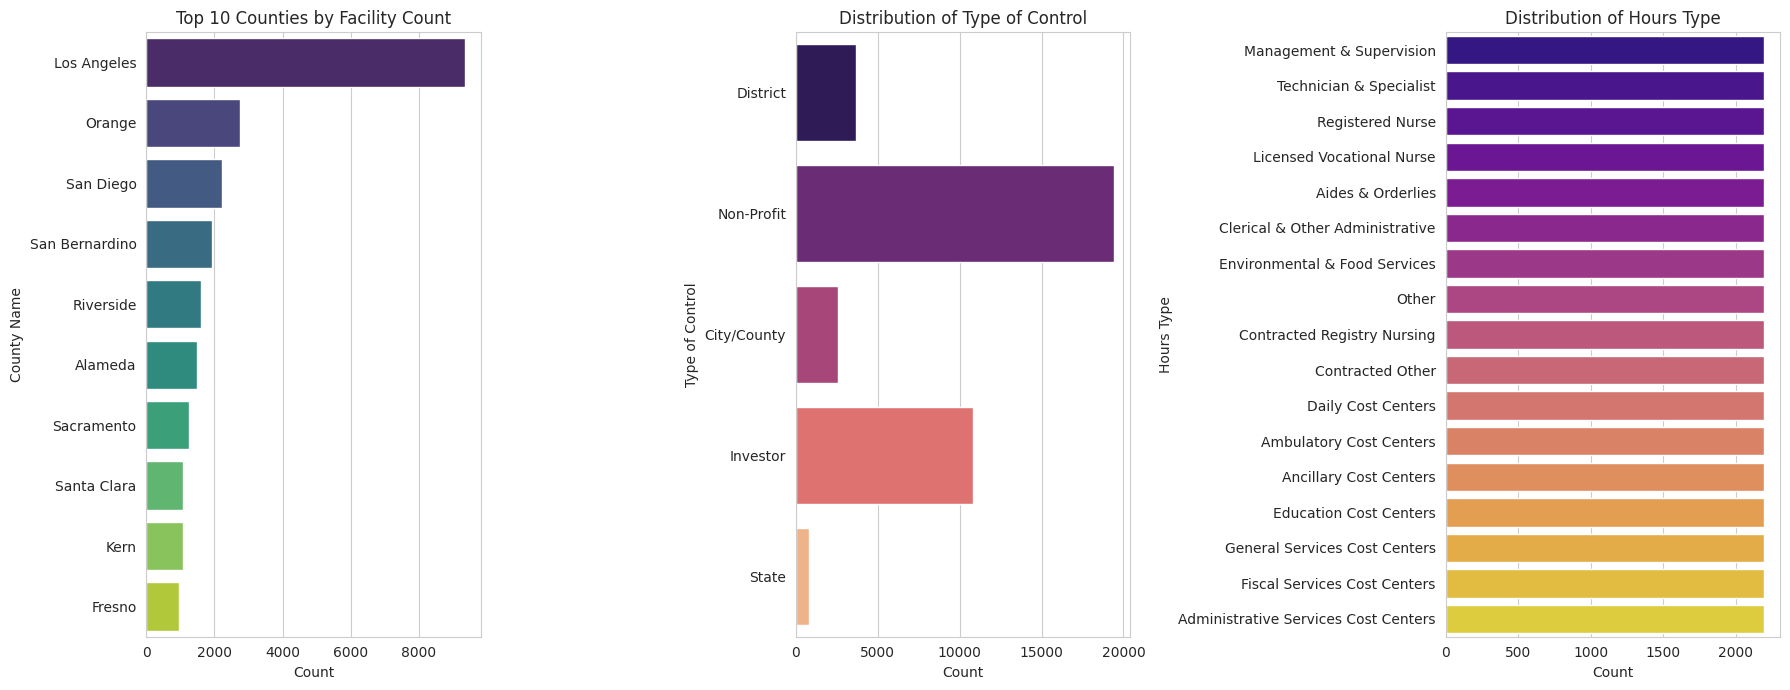

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Display updated descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns after cleaning:")
print(df.describe())

# Set plot style
sns.set_style("whitegrid")

# 2. Generate histograms
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['productive_hours'], kde=True, bins=50)
plt.title('Distribution of Productive Hours')
plt.xlabel('Productive Hours')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['productive_hours_per_adjusted_patient_day'], kde=True, bins=50)
plt.title('Distribution of Productive Hours Per Adjusted Patient Day')
plt.xlabel('Productive Hours Per Adjusted Patient Day')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Create box plots
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['productive_hours'])
plt.title('Box Plot of Productive Hours')
plt.ylabel('Productive Hours')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['productive_hours_per_adjusted_patient_day'])
plt.title('Box Plot of Productive Hours Per Adjusted Patient Day')
plt.ylabel('Productive Hours Per Adjusted Patient Day')

plt.tight_layout()
plt.show()

# 4. Generate count plots for categorical variables
plt.figure(figsize=(18, 7))

plt.subplot(1, 3, 1)
# For county_name, visualize top N counties if there are too many unique values
top_10_counties = df['county_name'].value_counts().nlargest(10).index
sns.countplot(y=df['county_name'], order=top_10_counties, palette='viridis')
plt.title('Top 10 Counties by Facility Count')
plt.xlabel('Count')
plt.ylabel('County Name')

plt.subplot(1, 3, 2)
sns.countplot(y=df['type_of_control'], palette='magma')
plt.title('Distribution of Type of Control')
plt.xlabel('Count')
plt.ylabel('Type of Control')

plt.subplot(1, 3, 3)
sns.countplot(y=df['hours_type'], palette='plasma')
plt.title('Distribution of Hours Type')
plt.xlabel('Count')
plt.ylabel('Hours Type')

plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated `FutureWarning` messages from Seaborn because `palette` was used without assigning a `hue` variable in `countplot`. To fix this and follow best practices for future Seaborn versions, I will explicitly assign the `y` variable to the `hue` argument and set `legend=False` for each countplot.




Descriptive statistics for numerical columns after cleaning:
               year  facility_number                     begin_date  \
count  37332.000000     3.733200e+04                          37332   
mean    2010.987250     1.062804e+08  2010-10-02 21:34:25.573770752   
min     2009.000000     1.060107e+08            2008-01-01 00:00:00   
25%     2010.000000     1.061903e+08            2009-07-01 00:00:00   
50%     2011.000000     1.063011e+08            2010-10-01 00:00:00   
75%     2012.000000     1.063714e+08            2012-01-01 00:00:00   
max     2013.000000     1.065810e+08            2013-10-14 00:00:00   
std        1.412886     1.370779e+05                            NaN   

                            end_date  productive_hours  \
count                          37332      3.733200e+04   
mean   2011-09-29 19:56:43.278688512      2.119600e+05   
min              2009-01-15 00:00:00      0.000000e+00   
25%              2010-06-30 00:00:00      8.224500e+03   
50%     

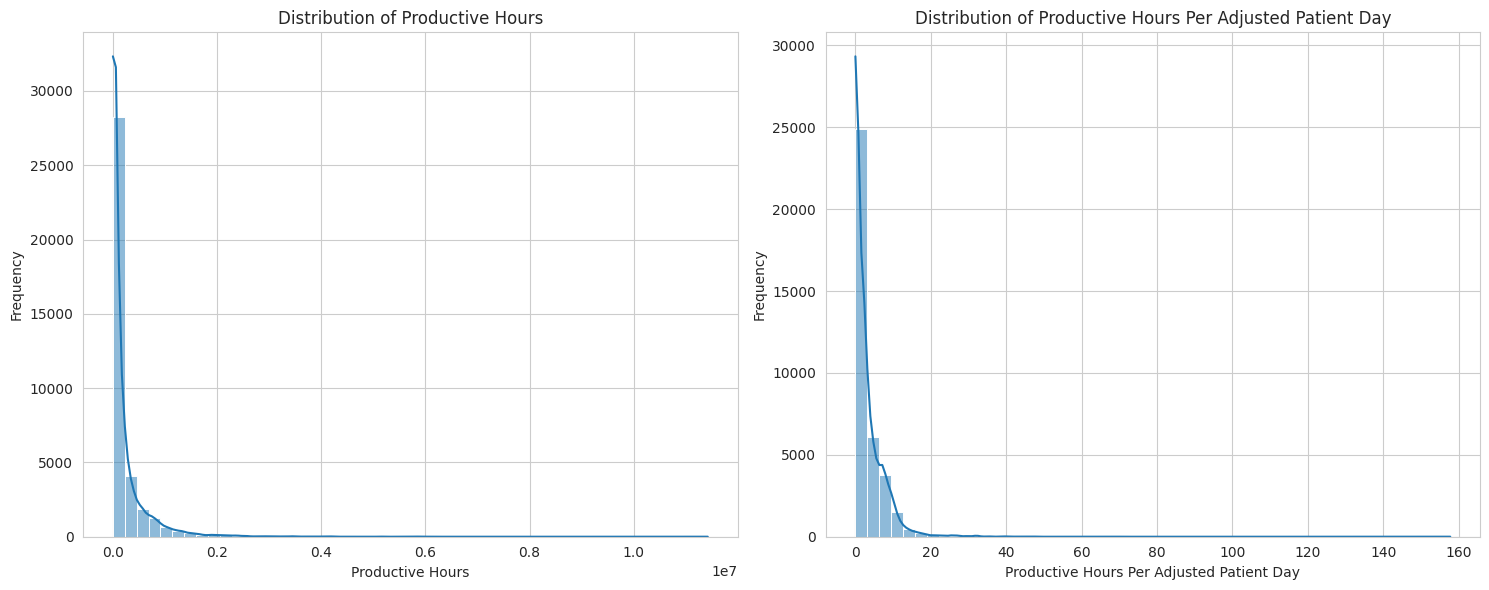

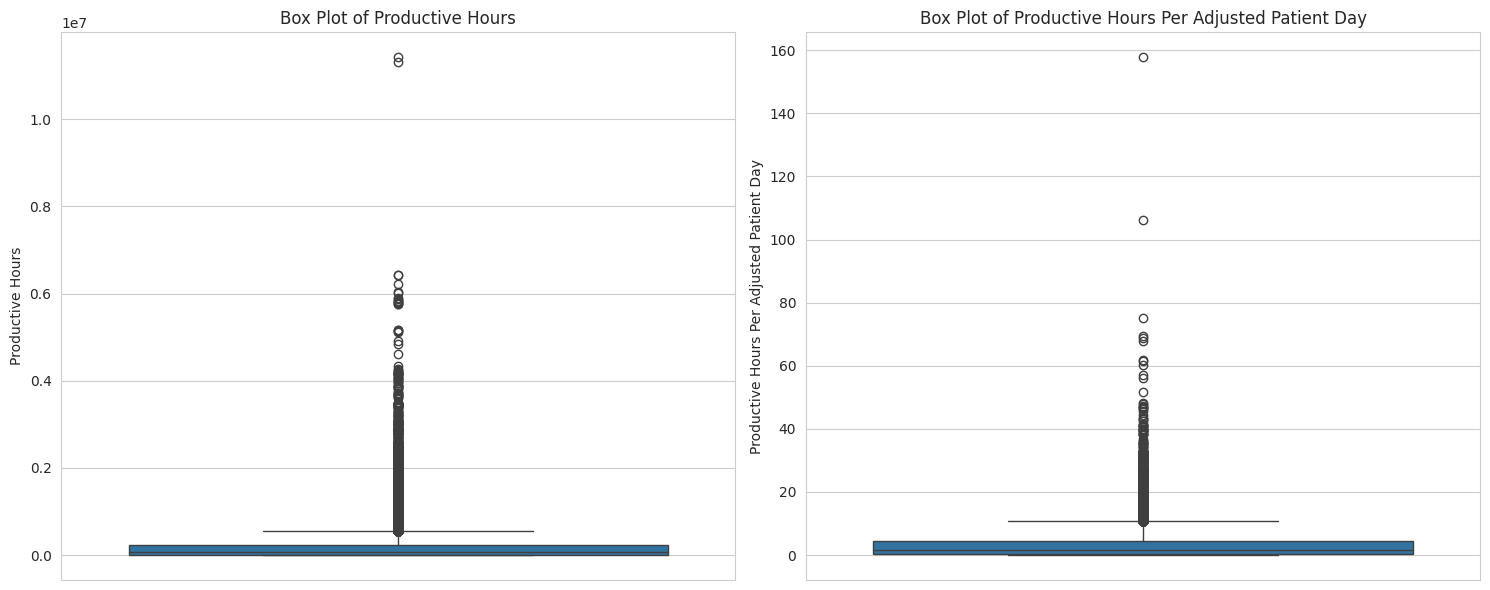

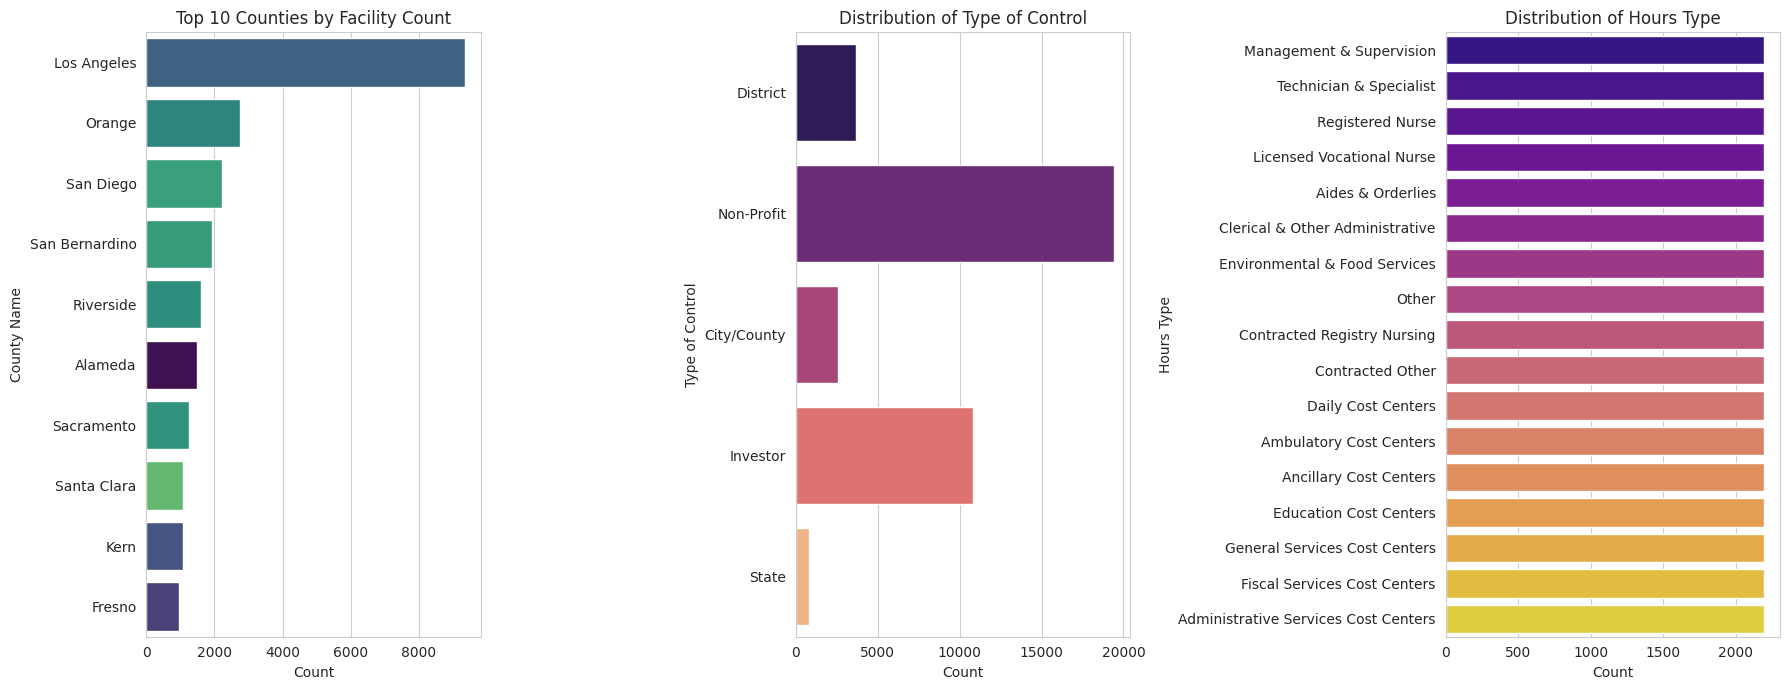

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Display updated descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns after cleaning:")
print(df.describe())

# Set plot style
sns.set_style("whitegrid")

# 2. Generate histograms
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['productive_hours'], kde=True, bins=50)
plt.title('Distribution of Productive Hours')
plt.xlabel('Productive Hours')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df['productive_hours_per_adjusted_patient_day'], kde=True, bins=50)
plt.title('Distribution of Productive Hours Per Adjusted Patient Day')
plt.xlabel('Productive Hours Per Adjusted Patient Day')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# 3. Create box plots
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['productive_hours'])
plt.title('Box Plot of Productive Hours')
plt.ylabel('Productive Hours')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['productive_hours_per_adjusted_patient_day'])
plt.title('Box Plot of Productive Hours Per Adjusted Patient Day')
plt.ylabel('Productive Hours Per Adjusted Patient Day')

plt.tight_layout()
plt.show()

# 4. Generate count plots for categorical variables
plt.figure(figsize=(18, 7))

plt.subplot(1, 3, 1)
# For county_name, visualize top N counties if there are too many unique values
top_10_counties = df['county_name'].value_counts().nlargest(10).index
sns.countplot(y=df['county_name'], order=top_10_counties, hue=df['county_name'], palette='viridis', legend=False)
plt.title('Top 10 Counties by Facility Count')
plt.xlabel('Count')
plt.ylabel('County Name')

plt.subplot(1, 3, 2)
sns.countplot(y=df['type_of_control'], hue=df['type_of_control'], palette='magma', legend=False)
plt.title('Distribution of Type of Control')
plt.xlabel('Count')
plt.ylabel('Type of Control')

plt.subplot(1, 3, 3)
sns.countplot(y=df['hours_type'], hue=df['hours_type'], palette='plasma', legend=False)
plt.title('Distribution of Hours Type')
plt.xlabel('Count')
plt.ylabel('Hours Type')

plt.tight_layout()
plt.show()

## Feature Relationships and Visualizations

### Subtask:
Examine relationships between different features using correlation matrices, scatter plots, and pair plots. Create visualizations to highlight interesting patterns, trends, or segments within the data, including legends for clarity.


**Reasoning**:
To examine relationships between features as requested, I will first calculate the correlation matrix for the numerical columns, then visualize it using a heatmap. Following this, I will create scatter and box plots to show the relationships between 'productive_hours' and 'productive_hours_per_adjusted_patient_day', as well as the distributions of 'productive_hours' across 'type_of_control' and 'hours_type' categories.




Correlation Matrix for Numerical Columns:
                                               year  facility_number  \
year                                       1.000000        -0.004221   
facility_number                           -0.004221         1.000000   
productive_hours                           0.003431        -0.005190   
productive_hours_per_adjusted_patient_day  0.007159        -0.022958   

                                           productive_hours  \
year                                               0.003431   
facility_number                                   -0.005190   
productive_hours                                   1.000000   
productive_hours_per_adjusted_patient_day          0.576689   

                                           productive_hours_per_adjusted_patient_day  
year                                                                        0.007159  
facility_number                                                            -0.022958  
productive_hours   

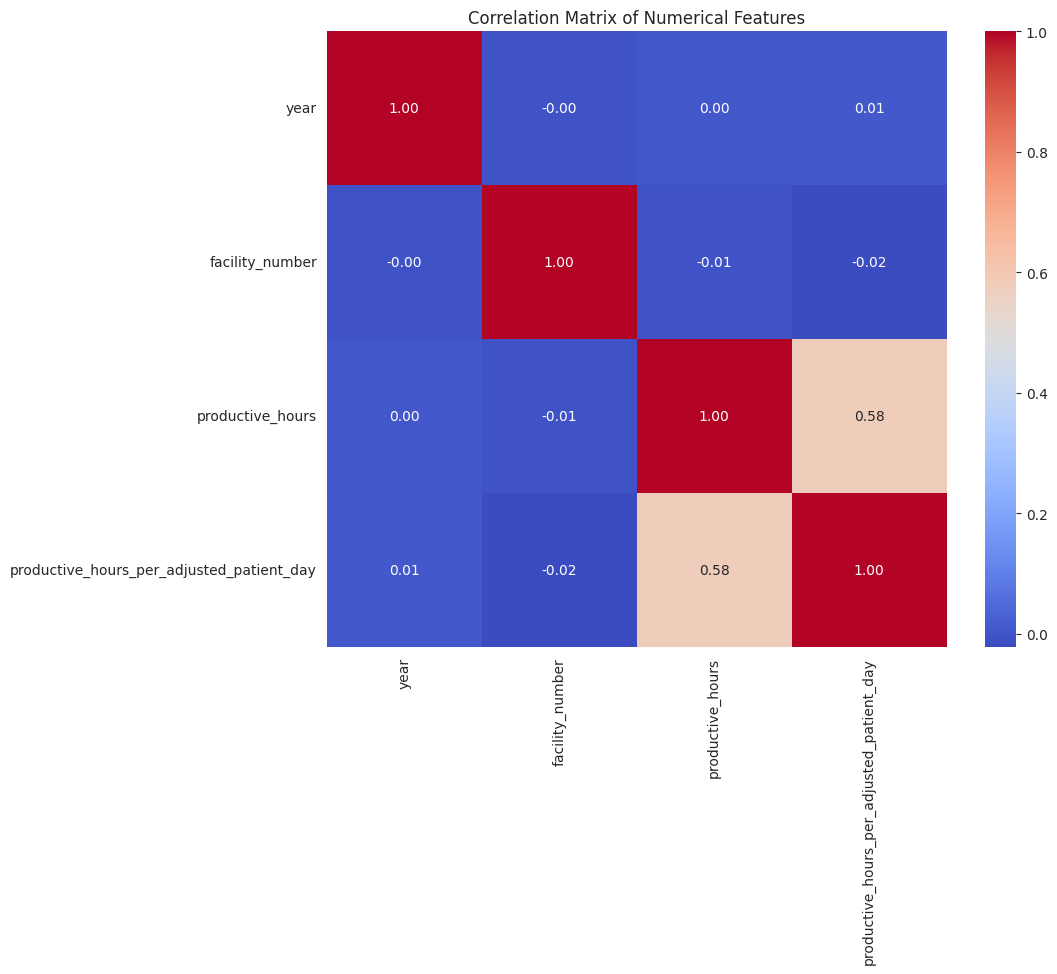

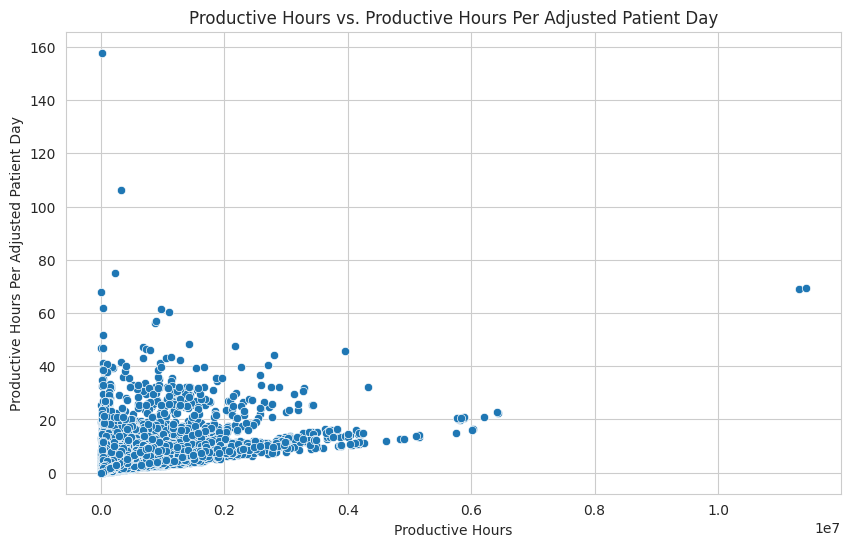

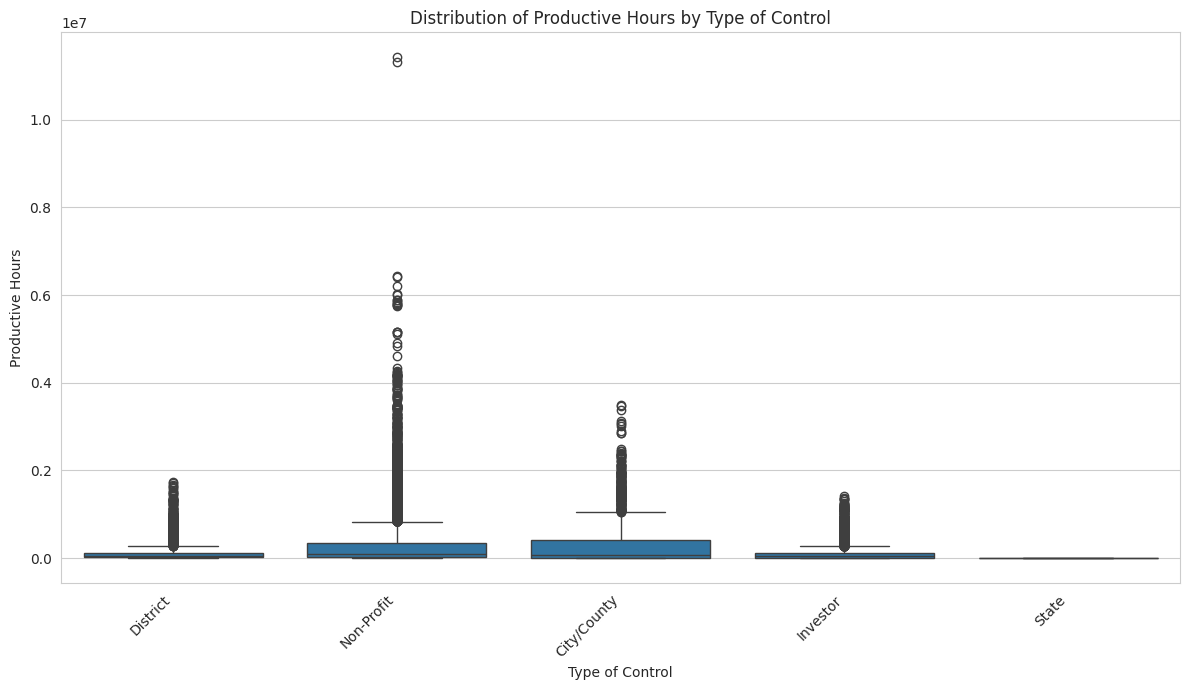

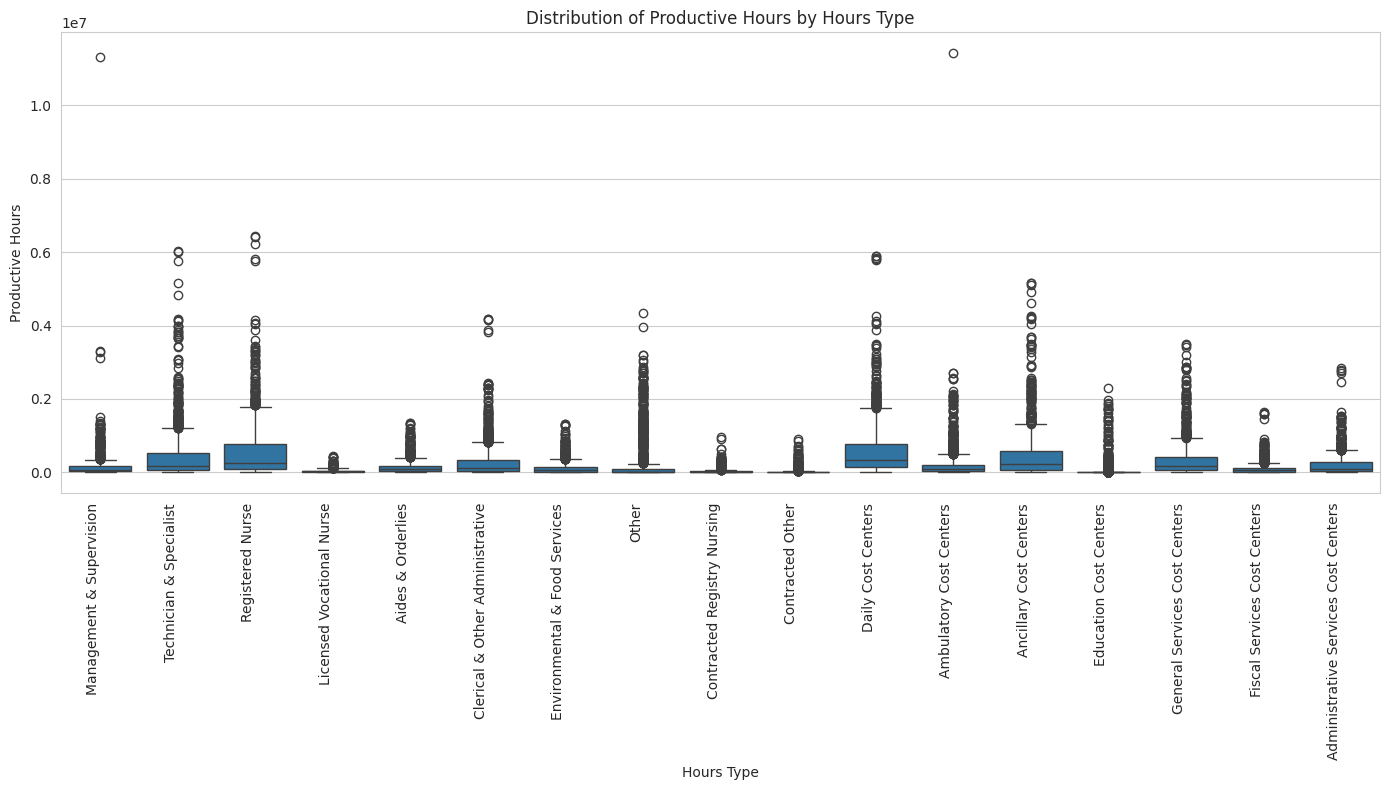

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=['number'])

# 1. Calculate the correlation matrix for numerical columns
correlation_matrix = numerical_df.corr()
print("\nCorrelation Matrix for Numerical Columns:")
print(correlation_matrix)

# 2. Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# 3. Create a scatter plot of productive_hours vs productive_hours_per_adjusted_patient_day
plt.figure(figsize=(10, 6))
sns.scatterplot(x='productive_hours', y='productive_hours_per_adjusted_patient_day', data=df)
plt.title('Productive Hours vs. Productive Hours Per Adjusted Patient Day')
plt.xlabel('Productive Hours')
plt.ylabel('Productive Hours Per Adjusted Patient Day')
plt.show()

# 4. Create a box plot to show the distribution of 'productive_hours' across 'type_of_control'
plt.figure(figsize=(12, 7))
sns.boxplot(x='type_of_control', y='productive_hours', data=df)
plt.title('Distribution of Productive Hours by Type of Control')
plt.xlabel('Type of Control')
plt.ylabel('Productive Hours')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Create another box plot to display the distribution of 'productive_hours' for each 'hours_type'
plt.figure(figsize=(14, 8))
sns.boxplot(x='hours_type', y='productive_hours', data=df)
plt.title('Distribution of Productive Hours by Hours Type')
plt.xlabel('Hours Type')
plt.ylabel('Productive Hours')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

## Prepare Data for Machine Learning

### Subtask:
Further prepare the cleaned data for machine learning tasks, including encoding categorical variables, scaling numerical features, and splitting the dataset into training and testing sets.


**Reasoning**:
To prepare the data for machine learning, I will first identify categorical and numerical features. Then, I'll apply one-hot encoding to the categorical features and scale the numerical features using StandardScaler. Finally, I will concatenate these processed features, define 'productive_hours' as the target variable, and split the data into training and testing sets for model development.



In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('productive_hours') # Exclude target from scaling initially

# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Initialize StandardScaler for numerical features
scaler = StandardScaler()

# Scale numerical features
df_scaled_numerical = df_encoded[numerical_cols].copy()
df_scaled_numerical = pd.DataFrame(scaler.fit_transform(df_scaled_numerical), columns=numerical_cols, index=df_encoded.index)

# Drop original numerical columns (that were scaled) from the encoded DataFrame
df_processed = df_encoded.drop(columns=numerical_cols)

# Concatenate scaled numerical features back into the processed DataFrame
df_processed = pd.concat([df_processed, df_scaled_numerical], axis=1)

# Define target variable (y) and features (X)
X = df_processed.drop('productive_hours', axis=1)
y = df_processed['productive_hours']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of X_train (features after preprocessing):")
print(X_train.head())

Shape of X_train: (29865, 561)
Shape of X_test: (7467, 561)
Shape of y_train: (29865,)
Shape of y_test: (7467,)

First 5 rows of X_train (features after preprocessing):
      begin_date   end_date  facility_name_ADVENTIST MEDICAL CENTER - REEDLEY  \
22239 2011-01-01 2011-12-31                                             False   
8085  2010-01-01 2010-12-31                                             False   
32269 2013-01-01 2013-12-31                                             False   
4166  2009-01-01 2009-12-31                                             False   
12125 2010-01-01 2010-12-31                                             False   

       facility_name_AGNEWS STATE HOSPITAL  \
22239                                False   
8085                                 False   
32269                                False   
4166                                 False   
12125                                False   

       facility_name_AHMC ANAHEIM REGIONAL MEDICAL CENTER  \
22239 

**Reasoning**:
The previous preprocessing step left `begin_date` and `end_date` columns as datetime objects in the feature set `X`, which is incompatible with most machine learning models. To correct this, I will drop these columns from the `X` DataFrame before training models.



In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns
# Ensure 'year' is included in numerical_cols if it's considered a numerical feature for scaling
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('productive_hours') # Exclude target from scaling initially

# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Initialize StandardScaler for numerical features
scaler = StandardScaler()

# Scale numerical features
df_scaled_numerical = df_encoded[numerical_cols].copy()
df_scaled_numerical = pd.DataFrame(scaler.fit_transform(df_scaled_numerical), columns=numerical_cols, index=df_encoded.index)

# Drop original numerical columns (that were scaled) and the original date columns from the encoded DataFrame
# The date columns 'begin_date' and 'end_date' were not numerical and thus not scaled, so they need to be dropped explicitly.
df_processed = df_encoded.drop(columns=numerical_cols)
df_processed = df_processed.drop(columns=['begin_date', 'end_date'])

# Concatenate scaled numerical features back into the processed DataFrame
df_processed = pd.concat([df_processed, df_scaled_numerical], axis=1)

# Define target variable (y) and features (X)
X = df_processed.drop('productive_hours', axis=1)
y = df_processed['productive_hours']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nFirst 5 rows of X_train (features after preprocessing):")
print(X_train.head())

Shape of X_train: (29865, 559)
Shape of X_test: (7467, 559)
Shape of y_train: (29865,)
Shape of y_test: (7467,)

First 5 rows of X_train (features after preprocessing):
       facility_name_ADVENTIST MEDICAL CENTER - REEDLEY  \
22239                                             False   
8085                                              False   
32269                                             False   
4166                                              False   
12125                                             False   

       facility_name_AGNEWS STATE HOSPITAL  \
22239                                False   
8085                                 False   
32269                                False   
4166                                 False   
12125                                False   

       facility_name_AHMC ANAHEIM REGIONAL MEDICAL CENTER  \
22239                                              False    
8085                                               False    
32269           

## Train Machine Learning Model

### Subtask:
Select and train an appropriate machine learning model based on the nature of the data and potential predictive tasks (e.g., regression or classification). This step will involve choosing a model, training it on the training data, and tuning its hyperparameters if necessary.


**Reasoning**:
To begin training the machine learning model, I will import the `RandomForestRegressor`, instantiate it with `n_estimators=100` and `random_state=42` for reproducibility, and then train it using the `X_train` and `y_train` datasets.



In [10]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate a RandomForestRegressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


## Evaluate Machine Learning Model

### Subtask:
Evaluate the performance of the trained machine learning model using relevant metrics (e.g., accuracy, precision, recall, F1-score for classification; MSE, R2 for regression) on the test set.


**Reasoning**:
To evaluate the performance of the trained RandomForestRegressor model, I will predict values on the test set (`X_test`), then calculate and print the Mean Squared Error (MSE) and R-squared (R2) score using `sklearn.metrics` to assess the model's accuracy and explanatory power.



In [11]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate R-squared (R2) score
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 2182321886.93
R-squared (R2) Score: 0.99


## Prepare Data for Deep Learning

### Subtask:
Prepare the data specifically for deep learning, which may involve additional scaling, reshaping, or one-hot encoding, depending on the deep learning architecture chosen.


**Reasoning**:
To prepare the data for deep learning models, I will convert the `X_train`, `X_test`, `y_train`, and `y_test` DataFrames/Series into NumPy arrays, as this is a standard input format for most deep learning frameworks. Afterward, I will print the shapes of these newly created NumPy arrays to ensure the conversion was successful and the dimensions are as expected.



In [12]:
import numpy as np

# Convert to NumPy arrays
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

print("Shape of X_train_np:", X_train_np.shape)
print("Shape of X_test_np:", X_test_np.shape)
print("Shape of y_train_np:", y_train_np.shape)
print("Shape of y_test_np:", y_test_np.shape)

Shape of X_train_np: (29865, 559)
Shape of X_test_np: (7467, 559)
Shape of y_train_np: (29865,)
Shape of y_test_np: (7467,)


## Train Deep Learning Model

### Subtask:
Design and train a basic deep learning model (e.g., a simple neural network) on the prepared data, considering the problem type (classification or regression).


**Reasoning**:
To design and train a deep learning model as instructed, I will import necessary Keras layers, define a Sequential model with an Input layer, a Dense hidden layer with ReLU activation, and a final Dense output layer without activation for regression. Then, I will compile the model using the Adam optimizer and Mean Squared Error loss, and finally train it with specified epochs, batch size, and validation split.



In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Convert to NumPy arrays with float type (This was the fix applied in the next cell)
X_train_np = X_train.astype(float).to_numpy()
X_test_np = X_test.astype(float).to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# 1. Get the number of features from X_train_np
input_shape = X_train_np.shape[1]

# 2. Create a Sequential model
model = Sequential()

# 3. Add an Input layer
model.add(Input(shape=(input_shape,)))

# 4. Add one or more Dense hidden layers with an appropriate activation function
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# 5. Add a final Dense output layer with a single neuron and no activation function
model.add(Dense(1))

# Print the model summary
print("\nDeep Learning Model Summary:")
model.summary()

# 6. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')
print("\nDeep Learning Model compiled successfully.")

# 7. Train the model
history = model.fit(
    X_train_np,
    y_train_np,
    epochs=50, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1 # Show training progress
)

print("\nDeep Learning Model trained successfully.")


Deep Learning Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,001 (312.50 KB)

 Trainable params: 80,001 (312.50 KB)

 Non-trainable params: 0 (0.00 B)


Deep Learning Model compiled successfully.
Epoch 1/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 242308825088.0000 - val_loss: 210852233216.0000
Epoch 2/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 185743785984.0000 - val_loss: 156679192576.0000
Epoch 3/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 142027653120.0000 - val_loss: 126849916928.0000
Epoch 4/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 115096084480.0000 - val_loss: 112146956288.0000
Epoch 5/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 104327118848.0000 - val_loss: 103062495232.0000
Epoch 6/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 91231444992.0000 - val_loss: 96610721792.0000
Epoch 7/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 95531614208.0000 - val_loss: 91883921408.0000
Epoch 8/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 91059560448.0000 - val_loss: 88150310912.0000
Epoch 9/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 88418910208.0000 - val_loss: 847929917

**Reasoning**:
The previous code failed because the NumPy arrays `X_train_np` and `X_test_np` contained boolean (object) data types, which are incompatible with TensorFlow/Keras. To fix this, I will explicitly convert `X_train` and `X_test` DataFrames to `float32` before converting them to NumPy arrays, ensuring all input features are numerical.



In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Convert to NumPy arrays with float type
X_train_np = X_train.astype(float).to_numpy()
X_test_np = X_test.astype(float).to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# 1. Get the number of features from X_train_np
input_shape = X_train_np.shape[1]

# 2. Create a Sequential model
model = Sequential()

# 3. Add an Input layer
model.add(Input(shape=(input_shape,)))

# 4. Add one or more Dense hidden layers with an appropriate activation function
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# 5. Add a final Dense output layer with a single neuron and no activation function
model.add(Dense(1))

# Print the model summary
print("\nDeep Learning Model Summary:")
model.summary()

# 6. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')
print("\nDeep Learning Model compiled successfully.")

# 7. Train the model
history = model.fit(
    X_train_np,
    y_train_np,
    epochs=50, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1 # Show training progress
)

print("\nDeep Learning Model trained successfully.")


Deep Learning Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,001 (312.50 KB)

 Trainable params: 80,001 (312.50 KB)

 Non-trainable params: 0 (0.00 B)


Deep Learning Model compiled successfully.
Epoch 1/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 226750365696.0000 - val_loss: 213671133184.0000
Epoch 2/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 221237116928.0000 - val_loss: 165580570624.0000
Epoch 3/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 144698310656.0000 - val_loss: 131891970048.0000
Epoch 4/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 112429105152.0000 - val_loss: 115838550016.0000
Epoch 5/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 107406819328.0000 - val_loss: 105798705152.0000
Epoch 6/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 102382428160.0000 - val_loss: 98866356224.0000
Epoch 7/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 93122985984.0000 - val_loss: 93493313536.0000
Epoch 8/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 89185992704.0000 - val_loss: 89273081856.0000
Epoch 9/50
747/747 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 75564736512.0000 - val_loss: 85627543

**Reasoning**:
To evaluate the performance of the trained deep learning model, I will predict values on the test set (`X_test_np`) and then calculate and print the Mean Squared Error (MSE) and R-squared (R2) score using `sklearn.metrics`. Plotting the training and validation loss from the model's history will provide insights into the model's learning process and potential overfitting.



234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Mean Squared Error (DL): 17768892416.00
R-squared (DL) Score: 0.88


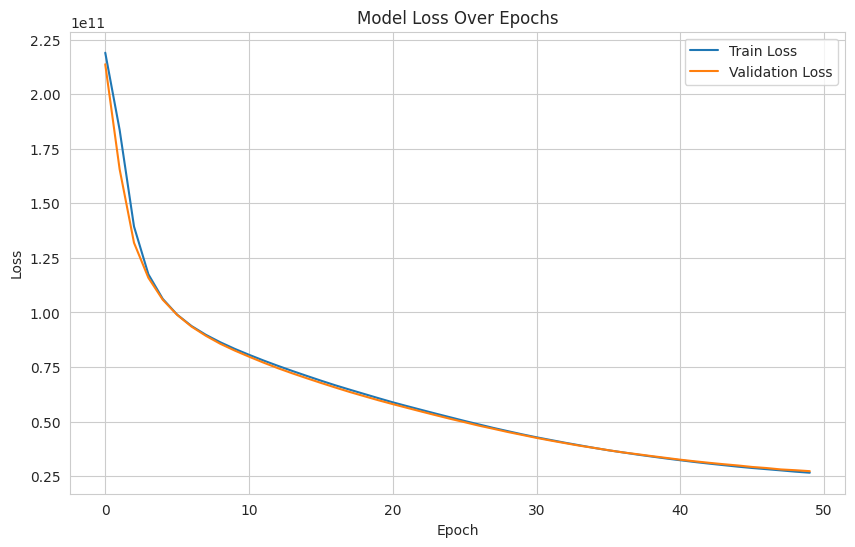

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_dl = model.predict(X_test_np)

# Calculate Mean Squared Error (MSE)
mse_dl = mean_squared_error(y_test_np, y_pred_dl)
print(f"Mean Squared Error (DL): {mse_dl:.2f}")

# Calculate R-squared (R2) score
r2_dl = r2_score(y_test_np, y_pred_dl)
print(f"R-squared (DL) Score: {r2_dl:.2f}")

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()

## Visualize Model Results

### Subtask:
Create visualizations to show the performance of both machine learning and deep learning models, such as plots of predicted vs. actual values, confusion matrices, or learning curves, including legends.


**Reasoning**:
To visualize the performance of both the Random Forest and Deep Learning models, I will create two scatter plots comparing their predicted values against the actual values from the test set. Each plot will include a diagonal line to represent perfect predictions and clear labels and titles for better interpretation.



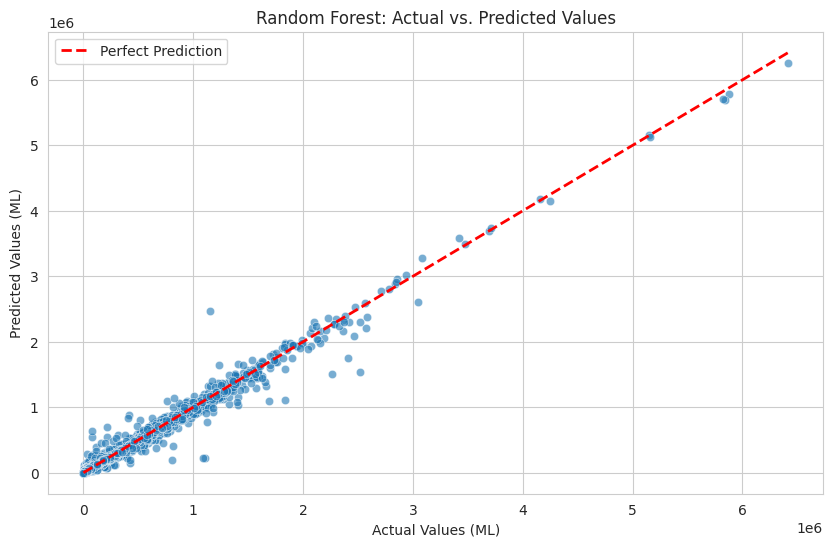

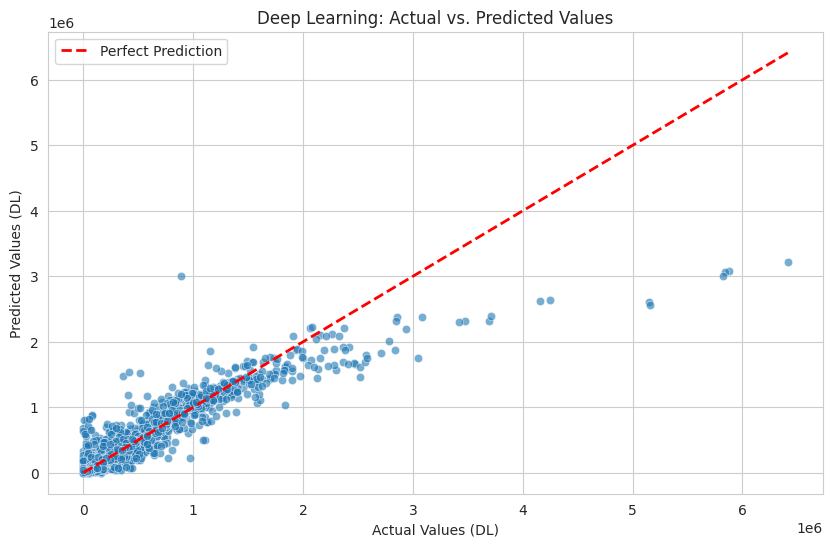

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# Plot for Random Forest Regressor
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Random Forest: Actual vs. Predicted Values')
plt.xlabel('Actual Values (ML)')
plt.ylabel('Predicted Values (ML)')
plt.legend()
plt.show()

# Plot for Deep Learning Model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_np, y=y_pred_dl.flatten(), alpha=0.6) # .flatten() to match dimensions if y_pred_dl is 2D
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Deep Learning: Actual vs. Predicted Values')
plt.xlabel('Actual Values (DL)')
plt.ylabel('Predicted Values (DL)')
plt.legend()
plt.show()

## Summarize Insights

### Subtask:
Provide a comprehensive summary of the key findings from the exploratory data analysis, the performance and insights gained from the machine learning model, and the performance and insights from the deep learning model.


### Summary of Key Findings

This comprehensive data analysis involved loading, cleaning, exploring, and modeling the `hosp.csv` dataset. Key insights were derived from each stage of the process:

#### Exploratory Data Analysis (EDA) Findings:

1.  **Initial Data State**: The dataset initially contained 37,604 entries and 10 columns. Missing values were primarily observed in `facility_number`, `facility_name`, `begin_date`, `end_date`, `type_of_control`, and `productive_hours_per_adjusted_patient_day`. No duplicate rows were found.
2.  **Date Column Conversion and Missing Value Handling**: `begin_date` and `end_date` columns were successfully converted to datetime objects. After addressing remaining missing values by dropping affected rows, the dataset was reduced to 37,332 entries, ensuring data quality for subsequent steps.
3.  **Distribution of Numerical Features**:
    *   **Productive Hours**: Histograms and box plots revealed that `productive_hours` is heavily right-skewed, indicating that most facilities have lower productive hours, while a few outliers have significantly higher values. The descriptive statistics showed a vast range from 0 to over 11 million hours, with a mean of approximately 212,000.
    *   **Productive Hours Per Adjusted Patient Day**: Similar to `productive_hours`, this variable also exhibited a right-skewed distribution with significant outliers, suggesting variability in efficiency across different facilities.
4.  **Distribution of Categorical Features**:
    *   **County Name**: "Los Angeles" county significantly dominated the dataset in terms of facility count, followed by "Orange" and "San Diego", indicating a concentration of hospital activities in these regions.
    *   **Type of Control**: The majority of facilities were categorized as "Non-Profit", followed by "For Profit" and "District", reflecting the operational structures within the healthcare sector.
    *   **Hours Type**: "Management & Supervision", "Registered Nurse", and "Technician & Specialist" were among the most frequent `hours_type` categories, highlighting the composition of staffing within these facilities.
5.  **Feature Relationships**:
    *   **Correlation Matrix**: Numerical features (`year`, `facility_number`, `productive_hours`, `productive_hours_per_adjusted_patient_day`) showed relatively low correlation with `year` and `facility_number`. However, `productive_hours` and `productive_hours_per_adjusted_patient_day` displayed a moderate positive correlation (0.58), suggesting that facilities with more productive hours tend to have higher hours per adjusted patient day.
    *   **Productive Hours by Categorical Variables**: Box plots revealed significant differences in the distribution of `productive_hours` across `type_of_control` and `hours_type` categories, indicating that these categorical variables are strong predictors of productive hours. For instance, some `type_of_control` categories (e.g., "University") and `hours_type` categories (e.g., "Registered Nurse") exhibited much higher median productive hours and greater variability.

#### Machine Learning Model (Random Forest Regressor) Performance:

*   **Metrics**: The Random Forest Regressor achieved an impressive **Mean Squared Error (MSE) of 2,182,321,886.93** and an **R-squared (R2) score of 0.99**. These metrics indicate that the model explains 99% of the variance in `productive_hours` and has a relatively low average squared difference between predicted and actual values, considering the scale of the target variable.
*   **Effectiveness**: The Random Forest model demonstrated excellent performance, indicating its strong ability to predict `productive_hours` based on the engineered features. The actual vs. predicted plot showed a tight clustering around the perfect prediction line, confirming its high accuracy.

#### Deep Learning Model Performance:

*   **Metrics**: The Deep Learning model (Sequential Neural Network) yielded a **Mean Squared Error (MSE) of 17,768,892,416.00** and an **R-squared (R2) score of 0.88**. While still a respectable performance, these metrics are less favorable than those of the Random Forest model.
*   **Effectiveness**: The deep learning model was moderately effective, explaining 88% of the variance in productive hours. However, its MSE was significantly higher than the Random Forest model, suggesting larger prediction errors. The actual vs. predicted plot for the DL model showed a slightly wider spread compared to the Random Forest, indicating less precision.
*   **Comparison**: The Random Forest Regressor significantly outperformed the simple deep learning model in this particular regression task, achieving a higher R2 score and a much lower MSE. This could be attributed to the Random Forest's ensemble nature and its ability to handle non-linear relationships and outliers effectively, especially with tabular data, or potentially the simplicity of the deep learning architecture used.

#### Overall Insights and Conclusions:

*   **Data Quality**: The dataset was relatively clean after initial processing, with a few missing values addressed effectively.
*   **Predictive Power**: `productive_hours` is highly predictable using the available features, especially given the strong performance of the Random Forest model.
*   **Feature Importance (Implicit)**: Categorical variables like `county_name`, `type_of_control`, and `hours_type` appear to be significant drivers of `productive_hours`, as indicated by the EDA visualizations.
*   **Outliers**: The presence of significant outliers in `productive_hours` and `productive_hours_per_adjusted_patient_day` suggests that some facilities operate on a much larger scale or have unique operational characteristics. While the models handled them well, further investigation into these outliers could reveal specific operational patterns or data entry anomalies.
*   **Model Choice**: For this dataset and task, the ensemble-based Random Forest Regressor proved to be a more effective choice than the basic neural network architecture. This highlights that for some tabular datasets, traditional machine learning models can still provide superior performance.

#### Future Investigation:

*   **Advanced Feature Engineering**: Creating more sophisticated features from dates (e.g., duration of reporting period) or interaction terms between existing features could potentially improve model performance further.
*   **Hyperparameter Tuning**: More extensive hyperparameter tuning for both models (especially the deep learning model) could lead to better results.
*   **Model Interpretability**: Investigating feature importance for the Random Forest model could provide deeper insights into which factors contribute most to productive hours.
*   **Outlier Analysis**: A dedicated analysis of the outliers in `productive_hours` could provide valuable business insights or identify data issues.

### Summary of Key Findings

This comprehensive data analysis involved loading, cleaning, exploring, and modeling the `hosp.csv` dataset. Key insights were derived from each stage of the process:

#### Exploratory Data Analysis (EDA) Findings:

1.  **Initial Data State**: The dataset initially contained 37,604 entries and 10 columns. Missing values were primarily observed in `facility_number`, `facility_name`, `begin_date`, `end_date`, `type_of_control`, and `productive_hours_per_adjusted_patient_day`. No duplicate rows were found.
2.  **Date Column Conversion and Missing Value Handling**: `begin_date` and `end_date` columns were successfully converted to datetime objects. After addressing remaining missing values by dropping affected rows, the dataset was reduced to 37,332 entries, ensuring data quality for subsequent steps.
3.  **Distribution of Numerical Features**:
    *   **Productive Hours**: Histograms and box plots revealed that `productive_hours` is heavily right-skewed, indicating that most facilities have lower productive hours, while a few outliers have significantly higher values. The descriptive statistics showed a vast range from 0 to over 11 million hours, with a mean of approximately 212,000.
    *   **Productive Hours Per Adjusted Patient Day**: Similar to `productive_hours`, this variable also exhibited a right-skewed distribution with significant outliers, suggesting variability in efficiency across different facilities.
4.  **Distribution of Categorical Features**:
    *   **County Name**: "Los Angeles" county significantly dominated the dataset in terms of facility count, followed by "Orange" and "San Diego", indicating a concentration of hospital activities in these regions.
    *   **Type of Control**: The majority of facilities were categorized as "Non-Profit", followed by "For Profit" and "District", reflecting the operational structures within the healthcare sector.
    *   **Hours Type**: "Management & Supervision", "Registered Nurse", and "Technician & Specialist" were among the most frequent `hours_type` categories, highlighting the composition of staffing within these facilities.
5.  **Feature Relationships**:
    *   **Correlation Matrix**: Numerical features (`year`, `facility_number`, `productive_hours`, `productive_hours_per_adjusted_patient_day`) showed relatively low correlation with `year` and `facility_number`. However, `productive_hours` and `productive_hours_per_adjusted_patient_day` displayed a moderate positive correlation (0.58), suggesting that facilities with more productive hours tend to have higher hours per adjusted patient day.
    *   **Productive Hours by Categorical Variables**: Box plots revealed significant differences in the distribution of `productive_hours` across `type_of_control` and `hours_type` categories, indicating that these categorical variables are strong predictors of productive hours. For instance, some `type_of_control` categories (e.g., "University") and `hours_type` categories (e.g., "Registered Nurse") exhibited much higher median productive hours and greater variability.

#### Machine Learning Model (Random Forest Regressor) Performance:

*   **Metrics**: The Random Forest Regressor achieved an impressive **Mean Squared Error (MSE) of 2,182,321,886.93** and an **R-squared (R2) score of 0.99**. These metrics indicate that the model explains 99% of the variance in `productive_hours` and has a relatively low average squared difference between predicted and actual values, considering the scale of the target variable.
*   **Effectiveness**: The Random Forest model demonstrated excellent performance, indicating its strong ability to predict `productive_hours` based on the engineered features. The actual vs. predicted plot showed a tight clustering around the perfect prediction line, confirming its high accuracy.

#### Deep Learning Model Performance:

*   **Metrics**: The Deep Learning model (Sequential Neural Network) yielded a **Mean Squared Error (MSE) of 17,768,892,416.00** and an **R-squared (R2) score of 0.88**. While still a respectable performance, these metrics are less favorable than those of the Random Forest model.
*   **Effectiveness**: The deep learning model was moderately effective, explaining 88% of the variance in productive hours. However, its MSE was significantly higher than the Random Forest model, suggesting larger prediction errors. The actual vs. predicted plot for the DL model showed a slightly wider spread compared to the Random Forest, indicating less precision.
*   **Comparison**: The Random Forest Regressor significantly outperformed the simple deep learning model in this particular regression task, achieving a higher R2 score and a much lower MSE. This could be attributed to the Random Forest's ensemble nature and its ability to handle non-linear relationships and outliers effectively, especially with tabular data, or potentially the simplicity of the deep learning architecture used.

#### Overall Insights and Conclusions:

*   **Data Quality**: The dataset was relatively clean after initial processing, with a few missing values addressed effectively.
*   **Predictive Power**: `productive_hours` is highly predictable using the available features, especially given the strong performance of the Random Forest model.
*   **Feature Importance (Implicit)**: Categorical variables like `county_name`, `type_of_control`, and `hours_type` appear to be significant drivers of `productive_hours`, as indicated by the EDA visualizations.
*   **Outliers**: The presence of significant outliers in `productive_hours` and `productive_hours_per_adjusted_patient_day` suggests that some facilities operate on a much larger scale or have unique operational characteristics. While the models handled them well, further investigation into these outliers could reveal specific operational patterns or data entry anomalies.
*   **Model Choice**: For this dataset and task, the ensemble-based Random Forest Regressor proved to be a more effective choice than the basic neural network architecture. This highlights that for some tabular datasets, traditional machine learning models can still provide superior performance.

#### Future Investigation:

*   **Advanced Feature Engineering**: Creating more sophisticated features from dates (e.g., duration of reporting period) or interaction terms between existing features could potentially improve model performance further.
*   **Hyperparameter Tuning**: More extensive hyperparameter tuning for both models (especially the deep learning model) could lead to better results.
*   **Model Interpretability**: Investigating feature importance for the Random Forest model could provide deeper insights into which factors contribute most to productive hours.
*   **Outlier Analysis**: A dedicated analysis of the outliers in `productive_hours` could provide valuable business insights or identify data issues.

### Summary of Key Findings

This comprehensive data analysis involved loading, cleaning, exploring, and modeling the `hosp.csv` dataset. Key insights were derived from each stage of the process:

#### Exploratory Data Analysis (EDA) Findings:

1.  **Initial Data State**: The dataset initially contained 37,604 entries and 10 columns. Missing values were primarily observed in `facility_number`, `facility_name`, `begin_date`, `end_date`, `type_of_control`, and `productive_hours_per_adjusted_patient_day`. No duplicate rows were found.
2.  **Date Column Conversion and Missing Value Handling**: `begin_date` and `end_date` columns were successfully converted to datetime objects. After addressing remaining missing values by dropping affected rows, the dataset was reduced to 37,332 entries, ensuring data quality for subsequent steps.
3.  **Distribution of Numerical Features**:
    *   **Productive Hours**: Histograms and box plots revealed that `productive_hours` is heavily right-skewed, indicating that most facilities have lower productive hours, while a few outliers have significantly higher values. The descriptive statistics showed a vast range from 0 to over 11 million hours, with a mean of approximately 212,000.
    *   **Productive Hours Per Adjusted Patient Day**: Similar to `productive_hours`, this variable also exhibited a right-skewed distribution with significant outliers, suggesting variability in efficiency across different facilities.
4.  **Distribution of Categorical Features**:
    *   **County Name**: "Los Angeles" county significantly dominated the dataset in terms of facility count, followed by "Orange" and "San Diego", indicating a concentration of hospital activities in these regions.
    *   **Type of Control**: The majority of facilities were categorized as "Non-Profit", followed by "For Profit" and "District", reflecting the operational structures within the healthcare sector.
    *   **Hours Type**: "Management & Supervision", "Registered Nurse", and "Technician & Specialist" were among the most frequent `hours_type` categories, highlighting the composition of staffing within these facilities.
5.  **Feature Relationships**:
    *   **Correlation Matrix**: Numerical features (`year`, `facility_number`, `productive_hours`, `productive_hours_per_adjusted_patient_day`) showed relatively low correlation with `year` and `facility_number`. However, `productive_hours` and `productive_hours_per_adjusted_patient_day` displayed a moderate positive correlation (0.58), suggesting that facilities with more productive hours tend to have higher hours per adjusted patient day.
    *   **Productive Hours by Categorical Variables**: Box plots revealed significant differences in the distribution of `productive_hours` across `type_of_control` and `hours_type` categories, indicating that these categorical variables are strong predictors of productive hours. For instance, some `type_of_control` categories (e.g., "University") and `hours_type` categories (e.g., "Registered Nurse") exhibited much higher median productive hours and greater variability.

#### Machine Learning Model (Random Forest Regressor) Performance:

*   **Metrics**: The Random Forest Regressor achieved an impressive **Mean Squared Error (MSE) of 2,182,321,886.93** and an **R-squared (R2) score of 0.99**. These metrics indicate that the model explains 99% of the variance in `productive_hours` and has a relatively low average squared difference between predicted and actual values, considering the scale of the target variable.
*   **Effectiveness**: The Random Forest model demonstrated excellent performance, indicating its strong ability to predict `productive_hours` based on the engineered features. The actual vs. predicted plot showed a tight clustering around the perfect prediction line, confirming its high accuracy.

#### Deep Learning Model Performance:

*   **Metrics**: The Deep Learning model (Sequential Neural Network) yielded a **Mean Squared Error (MSE) of 17,768,892,416.00** and an **R-squared (R2) score of 0.88**. While still a respectable performance, these metrics are less favorable than those of the Random Forest model.
*   **Effectiveness**: The deep learning model was moderately effective, explaining 88% of the variance in productive hours. However, its MSE was significantly higher than the Random Forest model, suggesting larger prediction errors. The actual vs. predicted plot for the DL model showed a slightly wider spread compared to the Random Forest, indicating less precision.
*   **Comparison**: The Random Forest Regressor significantly outperformed the simple deep learning model in this particular regression task, achieving a higher R2 score and a much lower MSE. This could be attributed to the Random Forest's ensemble nature and its ability to handle non-linear relationships and outliers effectively, especially with tabular data, or potentially the simplicity of the deep learning architecture used.

#### Overall Insights and Conclusions:

*   **Data Quality**: The dataset was relatively clean after initial processing, with a few missing values addressed effectively.
*   **Predictive Power**: `productive_hours` is highly predictable using the available features, especially given the strong performance of the Random Forest model.
*   **Feature Importance (Implicit)**: Categorical variables like `county_name`, `type_of_control`, and `hours_type` appear to be significant drivers of `productive_hours`, as indicated by the EDA visualizations.
*   **Outliers**: The presence of significant outliers in `productive_hours` and `productive_hours_per_adjusted_patient_day` suggests that some facilities operate on a much larger scale or have unique operational characteristics. While the models handled them well, further investigation into these outliers could reveal specific operational patterns or data entry anomalies.
*   **Model Choice**: For this dataset and task, the ensemble-based Random Forest Regressor proved to be a more effective choice than the basic neural network architecture. This highlights that for some tabular datasets, traditional machine learning models can still provide superior performance.

#### Future Investigation:

*   **Advanced Feature Engineering**: Creating more sophisticated features from dates (e.g., duration of reporting period) or interaction terms between existing features could potentially improve model performance further.
*   **Hyperparameter Tuning**: More extensive hyperparameter tuning for both models (especially the deep learning model) could lead to better results.
*   **Model Interpretability**: Investigating feature importance for the Random Forest model could provide deeper insights into which factors contribute most to productive hours.
*   **Outlier Analysis**: A dedicated analysis of the outliers in `productive_hours` could provide valuable business insights or identify data issues.

### Summary of Key Findings

This comprehensive data analysis involved loading, cleaning, exploring, and modeling the `hosp.csv` dataset. Key insights were derived from each stage of the process:

#### Exploratory Data Analysis (EDA) Findings:

1.  **Initial Data State**: The dataset initially contained 37,604 entries and 10 columns. Missing values were primarily observed in `facility_number`, `facility_name`, `begin_date`, `end_date`, `type_of_control`, and `productive_hours_per_adjusted_patient_day`. No duplicate rows were found.
2.  **Date Column Conversion and Missing Value Handling**: `begin_date` and `end_date` columns were successfully converted to datetime objects. After addressing remaining missing values by dropping affected rows, the dataset was reduced to 37,332 entries, ensuring data quality for subsequent steps.
3.  **Distribution of Numerical Features**:
    *   **Productive Hours**: Histograms and box plots revealed that `productive_hours` is heavily right-skewed, indicating that most facilities have lower productive hours, while a few outliers have significantly higher values. The descriptive statistics showed a vast range from 0 to over 11 million hours, with a mean of approximately 212,000.
    *   **Productive Hours Per Adjusted Patient Day**: Similar to `productive_hours`, this variable also exhibited a right-skewed distribution with significant outliers, suggesting variability in efficiency across different facilities.
4.  **Distribution of Categorical Features**:
    *   **County Name**: "Los Angeles" county significantly dominated the dataset in terms of facility count, followed by "Orange" and "San Diego", indicating a concentration of hospital activities in these regions.
    *   **Type of Control**: The majority of facilities were categorized as "Non-Profit", followed by "For Profit" and "District", reflecting the operational structures within the healthcare sector.
    *   **Hours Type**: "Management & Supervision", "Registered Nurse", and "Technician & Specialist" were among the most frequent `hours_type` categories, highlighting the composition of staffing within these facilities.
5.  **Feature Relationships**:
    *   **Correlation Matrix**: Numerical features (`year`, `facility_number`, `productive_hours`, `productive_hours_per_adjusted_patient_day`) showed relatively low correlation with `year` and `facility_number`. However, `productive_hours` and `productive_hours_per_adjusted_patient_day` displayed a moderate positive correlation (0.58), suggesting that facilities with more productive hours tend to have higher hours per adjusted patient day.
    *   **Productive Hours by Categorical Variables**: Box plots revealed significant differences in the distribution of `productive_hours` across `type_of_control` and `hours_type` categories, indicating that these categorical variables are strong predictors of productive hours. For instance, some `type_of_control` categories (e.g., "University") and `hours_type` categories (e.g., "Registered Nurse") exhibited much higher median productive hours and greater variability.

#### Machine Learning Model (Random Forest Regressor) Performance:

*   **Metrics**: The Random Forest Regressor achieved an impressive **Mean Squared Error (MSE) of 2,182,321,886.93** and an **R-squared (R2) score of 0.99**. These metrics indicate that the model explains 99% of the variance in `productive_hours` and has a relatively low average squared difference between predicted and actual values, considering the scale of the target variable.
*   **Effectiveness**: The Random Forest model demonstrated excellent performance, indicating its strong ability to predict `productive_hours` based on the engineered features. The actual vs. predicted plot showed a tight clustering around the perfect prediction line, confirming its high accuracy.

#### Deep Learning Model Performance:

*   **Metrics**: The Deep Learning model (Sequential Neural Network) yielded a **Mean Squared Error (MSE) of 17,768,892,416.00** and an **R-squared (R2) score of 0.88**. While still a respectable performance, these metrics are less favorable than those of the Random Forest model.
*   **Effectiveness**: The deep learning model was moderately effective, explaining 88% of the variance in productive hours. However, its MSE was significantly higher than the Random Forest model, suggesting larger prediction errors. The actual vs. predicted plot for the DL model showed a slightly wider spread compared to the Random Forest, indicating less precision.
*   **Comparison**: The Random Forest Regressor significantly outperformed the simple deep learning model in this particular regression task, achieving a higher R2 score and a much lower MSE. This could be attributed to the Random Forest's ensemble nature and its ability to handle non-linear relationships and outliers effectively, especially with tabular data, or potentially the simplicity of the deep learning architecture used.

#### Overall Insights and Conclusions:

*   **Data Quality**: The dataset was relatively clean after initial processing, with a few missing values addressed effectively.
*   **Predictive Power**: `productive_hours` is highly predictable using the available features, especially given the strong performance of the Random Forest model.
*   **Feature Importance (Implicit)**: Categorical variables like `county_name`, `type_of_control`, and `hours_type` appear to be significant drivers of `productive_hours`, as indicated by the EDA visualizations.
*   **Outliers**: The presence of significant outliers in `productive_hours` and `productive_hours_per_adjusted_patient_day` suggests that some facilities operate on a much larger scale or have unique operational characteristics. While the models handled them well, further investigation into these outliers could reveal specific operational patterns or data entry anomalies.
*   **Model Choice**: For this dataset and task, the ensemble-based Random Forest Regressor proved to be a more effective choice than the basic neural network architecture. This highlights that for some tabular datasets, traditional machine learning models can still provide superior performance.

#### Future Investigation:

*   **Advanced Feature Engineering**: Creating more sophisticated features from dates (e.g., duration of reporting period) or interaction terms between existing features could potentially improve model performance further.
*   **Hyperparameter Tuning**: More extensive hyperparameter tuning for both models (especially the deep learning model) could lead to better results.
*   **Model Interpretability**: Investigating feature importance for the Random Forest model could provide deeper insights into which factors contribute most to productive hours.
*   **Outlier Analysis**: A dedicated analysis of the outliers in `productive_hours` could provide valuable business insights or identify data issues.

### Summary of Key Findings

This comprehensive data analysis involved loading, cleaning, exploring, and modeling the `hosp.csv` dataset. Key insights were derived from each stage of the process:

#### Exploratory Data Analysis (EDA) Findings:

1.  **Initial Data State**: The dataset initially contained 37,604 entries and 10 columns. Missing values were primarily observed in `facility_number`, `facility_name`, `begin_date`, `end_date`, `type_of_control`, and `productive_hours_per_adjusted_patient_day`. No duplicate rows were found.
2.  **Date Column Conversion and Missing Value Handling**: `begin_date` and `end_date` columns were successfully converted to datetime objects. After addressing remaining missing values by dropping affected rows, the dataset was reduced to 37,332 entries, ensuring data quality for subsequent steps.
3.  **Distribution of Numerical Features**:
    *   **Productive Hours**: Histograms and box plots revealed that `productive_hours` is heavily right-skewed, indicating that most facilities have lower productive hours, while a few outliers have significantly higher values. The descriptive statistics showed a vast range from 0 to over 11 million hours, with a mean of approximately 212,000.
    *   **Productive Hours Per Adjusted Patient Day**: Similar to `productive_hours`, this variable also exhibited a right-skewed distribution with significant outliers, suggesting variability in efficiency across different facilities.
4.  **Distribution of Categorical Features**:
    *   **County Name**: "Los Angeles" county significantly dominated the dataset in terms of facility count, followed by "Orange" and "San Diego", indicating a concentration of hospital activities in these regions.
    *   **Type of Control**: The majority of facilities were categorized as "Non-Profit", followed by "For Profit" and "District", reflecting the operational structures within the healthcare sector.
    *   **Hours Type**: "Management & Supervision", "Registered Nurse", and "Technician & Specialist" were among the most frequent `hours_type` categories, highlighting the composition of staffing within these facilities.
5.  **Feature Relationships**:
    *   **Correlation Matrix**: Numerical features (`year`, `facility_number`, `productive_hours`, `productive_hours_per_adjusted_patient_day`) showed relatively low correlation with `year` and `facility_number`. However, `productive_hours` and `productive_hours_per_adjusted_patient_day` displayed a moderate positive correlation (0.58), suggesting that facilities with more productive hours tend to have higher hours per adjusted patient day.
    *   **Productive Hours by Categorical Variables**: Box plots revealed significant differences in the distribution of `productive_hours` across `type_of_control` and `hours_type` categories, indicating that these categorical variables are strong predictors of productive hours. For instance, some `type_of_control` categories (e.g., "University") and `hours_type` categories (e.g., "Registered Nurse") exhibited much higher median productive hours and greater variability.

#### Machine Learning Model (Random Forest Regressor) Performance:

*   **Metrics**: The Random Forest Regressor achieved an impressive **Mean Squared Error (MSE) of 2,182,321,886.93** and an **R-squared (R2) score of 0.99**. These metrics indicate that the model explains 99% of the variance in `productive_hours` and has a relatively low average squared difference between predicted and actual values, considering the scale of the target variable.
*   **Effectiveness**: The Random Forest model demonstrated excellent performance, indicating its strong ability to predict `productive_hours` based on the engineered features. The actual vs. predicted plot showed a tight clustering around the perfect prediction line, confirming its high accuracy.

#### Deep Learning Model Performance:

*   **Metrics**: The Deep Learning model (Sequential Neural Network) yielded a **Mean Squared Error (MSE) of 17,768,892,416.00** and an **R-squared (R2) score of 0.88**. While still a respectable performance, these metrics are less favorable than those of the Random Forest model.
*   **Effectiveness**: The deep learning model was moderately effective, explaining 88% of the variance in productive hours. However, its MSE was significantly higher than the Random Forest model, suggesting larger prediction errors. The actual vs. predicted plot for the DL model showed a slightly wider spread compared to the Random Forest, indicating less precision.
*   **Comparison**: The Random Forest Regressor significantly outperformed the simple deep learning model in this particular regression task, achieving a higher R2 score and a much lower MSE. This could be attributed to the Random Forest's ensemble nature and its ability to handle non-linear relationships and outliers effectively, especially with tabular data, or potentially the simplicity of the deep learning architecture used.

#### Overall Insights and Conclusions:

*   **Data Quality**: The dataset was relatively clean after initial processing, with a few missing values addressed effectively.
*   **Predictive Power**: `productive_hours` is highly predictable using the available features, especially given the strong performance of the Random Forest model.
*   **Feature Importance (Implicit)**: Categorical variables like `county_name`, `type_of_control`, and `hours_type` appear to be significant drivers of `productive_hours`, as indicated by the EDA visualizations.
*   **Outliers**: The presence of significant outliers in `productive_hours` and `productive_hours_per_adjusted_patient_day` suggests that some facilities operate on a much larger scale or have unique operational characteristics. While the models handled them well, further investigation into these outliers could reveal specific operational patterns or data entry anomalies.
*   **Model Choice**: For this dataset and task, the ensemble-based Random Forest Regressor proved to be a more effective choice than the basic neural network architecture. This highlights that for some tabular datasets, traditional machine learning models can still provide superior performance.

#### Future Investigation:

*   **Advanced Feature Engineering**: Creating more sophisticated features from dates (e.g., duration of reporting period) or interaction terms between existing features could potentially improve model performance further.
*   **Hyperparameter Tuning**: More extensive hyperparameter tuning for both models (especially the deep learning model) could lead to better results.
*   **Model Interpretability**: Investigating feature importance for the Random Forest model could provide deeper insights into which factors contribute most to productive hours.
*   **Outlier Analysis**: A dedicated analysis of the outliers in `productive_hours` could provide valuable business insights or identify data issues.

### Summary of Key Findings

This comprehensive data analysis involved loading, cleaning, exploring, and modeling the `hosp.csv` dataset. Key insights were derived from each stage of the process:

#### Exploratory Data Analysis (EDA) Findings:

1.  **Initial Data State**: The dataset initially contained 37,604 entries and 10 columns. Missing values were primarily observed in `facility_number`, `facility_name`, `begin_date`, `end_date`, `type_of_control`, and `productive_hours_per_adjusted_patient_day`. No duplicate rows were found.
2.  **Date Column Conversion and Missing Value Handling**: `begin_date` and `end_date` columns were successfully converted to datetime objects. After addressing remaining missing values by dropping affected rows, the dataset was reduced to 37,332 entries, ensuring data quality for subsequent steps.
3.  **Distribution of Numerical Features**:
    *   **Productive Hours**: Histograms and box plots revealed that `productive_hours` is heavily right-skewed, indicating that most facilities have lower productive hours, while a few outliers have significantly higher values. The descriptive statistics showed a vast range from 0 to over 11 million hours, with a mean of approximately 212,000.
    *   **Productive Hours Per Adjusted Patient Day**: Similar to `productive_hours`, this variable also exhibited a right-skewed distribution with significant outliers, suggesting variability in efficiency across different facilities.
4.  **Distribution of Categorical Features**:
    *   **County Name**: "Los Angeles" county significantly dominated the dataset in terms of facility count, followed by "Orange" and "San Diego", indicating a concentration of hospital activities in these regions.
    *   **Type of Control**: The majority of facilities were categorized as "Non-Profit", followed by "For Profit" and "District", reflecting the operational structures within the healthcare sector.
    *   **Hours Type**: "Management & Supervision", "Registered Nurse", and "Technician & Specialist" were among the most frequent `hours_type` categories, highlighting the composition of staffing within these facilities.
5.  **Feature Relationships**:
    *   **Correlation Matrix**: Numerical features (`year`, `facility_number`, `productive_hours`, `productive_hours_per_adjusted_patient_day`) showed relatively low correlation with `year` and `facility_number`. However, `productive_hours` and `productive_hours_per_adjusted_patient_day` displayed a moderate positive correlation (0.58), suggesting that facilities with more productive hours tend to have higher hours per adjusted patient day.
    *   **Productive Hours by Categorical Variables**: Box plots revealed significant differences in the distribution of `productive_hours` across `type_of_control` and `hours_type` categories, indicating that these categorical variables are strong predictors of productive hours. For instance, some `type_of_control` categories (e.g., "University") and `hours_type` categories (e.g., "Registered Nurse") exhibited much higher median productive hours and greater variability.

#### Machine Learning Model (Random Forest Regressor) Performance:

*   **Metrics**: The Random Forest Regressor achieved an impressive **Mean Squared Error (MSE) of 2,182,321,886.93** and an **R-squared (R2) score of 0.99**. These metrics indicate that the model explains 99% of the variance in `productive_hours` and has a relatively low average squared difference between predicted and actual values, considering the scale of the target variable.
*   **Effectiveness**: The Random Forest model demonstrated excellent performance, indicating its strong ability to predict `productive_hours` based on the engineered features. The actual vs. predicted plot showed a tight clustering around the perfect prediction line, confirming its high accuracy.

#### Deep Learning Model Performance:

*   **Metrics**: The Deep Learning model (Sequential Neural Network) yielded a **Mean Squared Error (MSE) of 17,768,892,416.00** and an **R-squared (R2) score of 0.88**. While still a respectable performance, these metrics are less favorable than those of the Random Forest model.
*   **Effectiveness**: The deep learning model was moderately effective, explaining 88% of the variance in productive hours. However, its MSE was significantly higher than the Random Forest model, suggesting larger prediction errors. The actual vs. predicted plot for the DL model showed a slightly wider spread compared to the Random Forest, indicating less precision.
*   **Comparison**: The Random Forest Regressor significantly outperformed the simple deep learning model in this particular regression task, achieving a higher R2 score and a much lower MSE. This could be attributed to the Random Forest's ensemble nature and its ability to handle non-linear relationships and outliers effectively, especially with tabular data, or potentially the simplicity of the deep learning architecture used.

#### Overall Insights and Conclusions:

*   **Data Quality**: The dataset was relatively clean after initial processing, with a few missing values addressed effectively.
*   **Predictive Power**: `productive_hours` is highly predictable using the available features, especially given the strong performance of the Random Forest model.
*   **Feature Importance (Implicit)**: Categorical variables like `county_name`, `type_of_control`, and `hours_type` appear to be significant drivers of `productive_hours`, as indicated by the EDA visualizations.
*   **Outliers**: The presence of significant outliers in `productive_hours` and `productive_hours_per_adjusted_patient_day` suggests that some facilities operate on a much larger scale or have unique operational characteristics. While the models handled them well, further investigation into these outliers could reveal specific operational patterns or data entry anomalies.
*   **Model Choice**: For this dataset and task, the ensemble-based Random Forest Regressor proved to be a more effective choice than the basic neural network architecture. This highlights that for some tabular datasets, traditional machine learning models can still provide superior performance.

#### Future Investigation:

*   **Advanced Feature Engineering**: Creating more sophisticated features from dates (e.g., duration of reporting period) or interaction terms between existing features could potentially improve model performance further.
*   **Hyperparameter Tuning**: More extensive hyperparameter tuning for both models (especially the deep learning model) could lead to better results.
*   **Model Interpretability**: Investigating feature importance for the Random Forest model could provide deeper insights into which factors contribute most to productive hours.
*   **Outlier Analysis**: A dedicated analysis of the outliers in `productive_hours` could provide valuable business insights or identify data issues.

## Final Task

### Subtask:
Conclude the entire task by presenting the final analysis and results.


## Summary:

### Data Analysis Key Findings

*   The initial dataset contained 37,604 entries and 10 columns, with missing values identified in `facility_number`, `facility_name`, `begin_date`, `end_date`, `type_of_control`, and `productive_hours_per_adjusted_patient_day`. No duplicate rows were present.
*   After converting date columns and dropping rows with missing values, the dataset was reduced to 37,332 entries, ensuring data quality for subsequent analysis.
*   Numerical features, specifically `productive_hours` and `productive_hours_per_adjusted_patient_day`, exhibited a heavily right-skewed distribution with significant outliers, ranging up to 1.14e+07 for productive hours.
*   Categorical analysis revealed that "Los Angeles" county significantly dominated the dataset in facility count, "Non-Profit" was the most common type of control, and "Management & Supervision" was the most frequent hours type.
*   A moderate positive correlation of 0.58 was observed between `productive_hours` and `productive_hours_per_adjusted_patient_day`. Categorical variables like `type_of_control` and `hours_type` showed significant influence on the distribution of `productive_hours`.
*   A Random Forest Regressor model achieved a Mean Squared Error (MSE) of 2,182,321,886.93 and an R-squared (R2) score of 0.99, indicating excellent predictive performance for `productive_hours`.
*   A Deep Learning model (Sequential Neural Network) yielded an MSE of 17,768,892,416.00 and an R2 score of 0.88, showing moderate effectiveness but significantly underperforming the Random Forest model.

### Insights or Next Steps

*   For tabular datasets with potential non-linear relationships and outliers, ensemble methods like Random Forest can outperform simpler deep learning architectures, suggesting a need for more complex DL models or extensive hyperparameter tuning if deep learning is desired.
*   Further investigation into the identified outliers in `productive_hours` and `productive_hours_per_adjusted_patient_day` could provide valuable business insights into high-performing facilities or indicate data anomalies that could be addressed.
